# Problema 1

In [ ]:
#Cargo codigo R en GCP (google colab enterprise)
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [ ]:
%%R

install.packages(c("ggplot2", "dplyr", "caret", "corrplot", "gridExtra"))


#cargar las distintas librerias
library(MASS) #lda
library(tidyr)
library(ggplot2) #graficos
library(dplyr) # manipulacion de datos
library(caret) # particion estratificada
library(corrplot) #matriz de correlacion
library(gridExtra) # cambinar multiples graficos

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/ggplot2_4.0.3.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/dplyr_1.2.1.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/caret_7.0-1.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/corrplot_0.95.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/gridExtra_2.3.1.tar.gz'

The downloaded source packages are in
	‘/tmp/RtmpaTk7tx/downloaded_packages’


In [ ]:
#cargar el archivo desde GCS a la máquina virtual
%%R
system("gsutil cp 'gs://all-in-master/MÉTODOS ESTADÍSTICOS PARA LA CIENCIA DE DATOS/generate_submission.csv' /tmp/generate_submission.csv")

#leer el archivo
datos_gerente <- read.csv("/tmp/generate_submission.csv")

In [ ]:
%%R

#mostrar los primeros registros
head(datos_gerente)

  Hotel  Tipo_hotel Ocupacion_semana_pct Ocupacion_fin_semana_pct
1 HT001 Corporativo                 96.0                     46.7
2 HT002  Vacacional                 66.1                     82.0
3 HT003  Vacacional                 55.0                     81.0
4 HT004 Corporativo                 94.3                     51.6
5 HT005 Corporativo                 71.7                     42.7
6 HT006 Corporativo                 96.0                     47.9
  Estancia_promedio_noches Anticipacion_reserva_dias Tarifa_promedio_miles
1                      1.2                         9                   277
2                      4.0                        29                   322
3                      3.9                        38                   324
4                      1.2                         8                   280
5                      1.6                         9                   275
6                      1.2                         3                   277
  Reservas_gr

In [ ]:
#ver todas las variables en el archivo
%%R
names(datos_gerente)

 [1] "Hotel"                     "Tipo_hotel"               
 [3] "Ocupacion_semana_pct"      "Ocupacion_fin_semana_pct" 
 [5] "Estancia_promedio_noches"  "Anticipacion_reserva_dias"
 [7] "Tarifa_promedio_miles"     "Reservas_grupales_pct"    
 [9] "Consumo_adicional_miles"   "Cancelaciones_pct"        


In [ ]:
%%R
#ver si hay datos nulos en el dataset
anyNA(datos_gerente)

[1] FALSE


In [ ]:
%%R
#ver el tipo de dato de las variables
str(datos_gerente)

'data.frame':	108 obs. of  10 variables:
 $ Hotel                    : chr  "HT001" "HT002" "HT003" "HT004" ...
 $ Tipo_hotel               : chr  "Corporativo" "Vacacional" "Vacacional" "Corporativo" ...
 $ Ocupacion_semana_pct     : num  96 66.1 55 94.3 71.7 96 77.6 82.5 57.9 90.7 ...
 $ Ocupacion_fin_semana_pct : num  46.7 82 81 51.6 42.7 47.9 47.5 49.2 83 77.2 ...
 $ Estancia_promedio_noches : num  1.2 4 3.9 1.2 1.6 1.2 1.6 1.2 3.4 2.8 ...
 $ Anticipacion_reserva_dias: int  9 29 38 8 9 3 11 10 19 19 ...
 $ Tarifa_promedio_miles    : int  277 322 324 280 275 277 311 233 291 290 ...
 $ Reservas_grupales_pct    : num  47.2 14.8 14.5 47.5 35.7 55 35.6 31 11.5 38.9 ...
 $ Consumo_adicional_miles  : int  81 196 221 86 111 50 123 78 155 136 ...
 $ Cancelaciones_pct        : num  13 13.9 7.5 13.2 16.9 14.8 10.8 13.7 9.7 5 ...


La unidad de observación es cada hotel (108 en total, identificados por la columna Hotel). La variable de grupo es Tipo_hotel, con tres clases: Corporativo, Vacacional y Mixto. Las 8 variables restantes (de Ocupacion_semana_pct a Cancelaciones_pct), todas numéricas, actúan como predictoras operativas y comerciales.

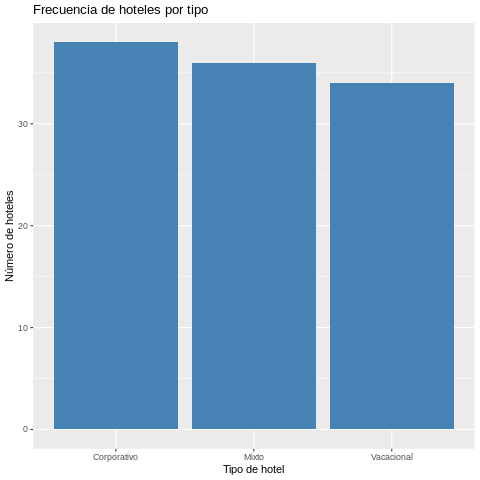

In [ ]:
%%R
#se genera una grafica de barras para ver si las 3 clases estan balanceadas
ggplot(datos_gerente, aes(x = Tipo_hotel)) +
  geom_bar(fill = "steelblue") +
  labs(title = "Frecuencia de hoteles por tipo",
       x = "Tipo de hotel", y = "Número de hoteles")

Las tres clases de hoteles están muy bien balanceadas, con frecuencias casi iguales. Corporativo es el tipo más frecuente, seguido de Mixto, y Vacacional es el menos numeroso, aunque las diferencias entre ellos son mínimas.

In [ ]:
%%R
#saco las variables que no son numericas
datos_numericos <- datos_gerente %>% select(-Hotel, -Tipo_hotel)

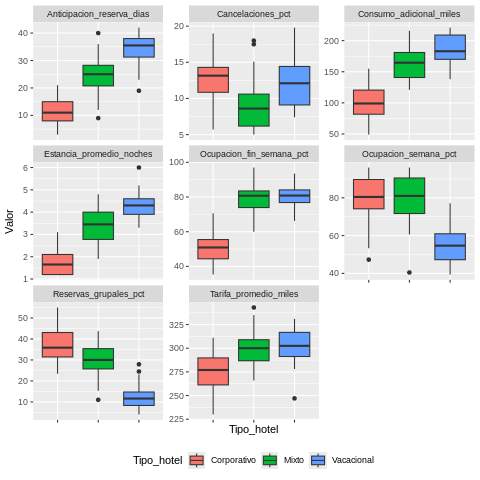

In [ ]:
%%R
#boxplots predictora vs tipo de hotel, la exploración bivariada
datos_long <- datos_gerente %>%
  select(-Hotel) %>%
  pivot_longer(cols = -Tipo_hotel, names_to = "Variable", values_to = "Valor")

ggplot(datos_long, aes(x = Tipo_hotel, y = Valor, fill = Tipo_hotel)) +
  geom_boxplot() +
  facet_wrap(~ Variable, scales = "free_y") +
  theme(axis.text.x = element_blank(), legend.position = "bottom")

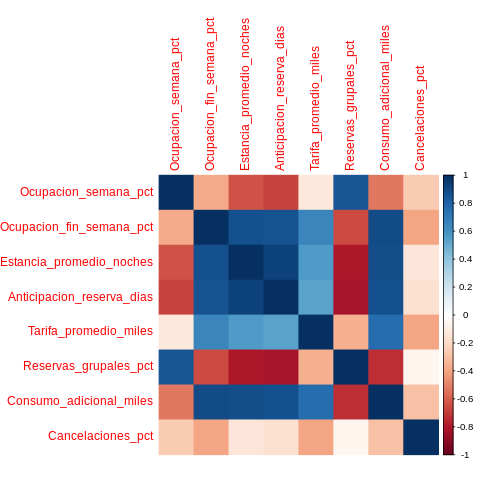

In [ ]:
%%R
#matriz de correlacion
matriz <- cor(datos_numericos)
corrplot(matriz, method = "color")

La matriz de correlación muestra un bloque de variables asociadas al perfil vacacional que se correlacionan positivamente entre sí: ocupación de fin de semana, estancia promedio, anticipación de reserva y consumo adicional tienden a subir juntas. En contraste, Reservas_grupales_pct y Ocupacion_semana_pct presentan relación inversa fuerte con ese bloque (a más reservas grupales y ocupación entre semana, menor estancia, anticipación y consumo), reflejando el perfil corporativo opuesto al vacacional. Estas correlaciones marcadas indican cierta colinealidad entre las predictoras, lo cual conviene considerar al interpretar el análisis discriminante.



In [ ]:
%%R
#creo el data frame, incluyendo Tipo_hotel (quitando Hotel)
Datos_modelo <- datos_gerente %>% select(-Hotel)

In [ ]:
%%R
#ajuste del modelo con la muestra completa
modelo <- lda(Tipo_hotel ~ ., data = Datos_modelo)

In [ ]:
%%R
#mostrar modelo
modelo

Call:
lda(Tipo_hotel ~ ., data = Datos_modelo)

Prior probabilities of groups:
Corporativo       Mixto  Vacacional 
  0.3518519   0.3333333   0.3148148 

Group means:
            Ocupacion_semana_pct Ocupacion_fin_semana_pct
Corporativo             80.42368                 50.58421
Mixto                   80.19444                 78.49167
Vacacional              54.44412                 80.30294
            Estancia_promedio_noches Anticipacion_reserva_dias
Corporativo                 1.784211                  11.36842
Mixto                       3.361111                  25.33333
Vacacional                  4.291176                  33.91176
            Tarifa_promedio_miles Reservas_grupales_pct Consumo_adicional_miles
Corporativo              273.6579              37.23684                99.18421
Mixto                    299.2500              30.02500               164.05556
Vacacional               303.2941              12.52941               186.52941
            Cancelaciones_pct

Al haber 3 grupos, el modelo genera 2 funciones discriminantes. LD1 concentra el 77.91% de la capacidad de separación entre grupos y LD2 el 22.09%, por lo que ambas funciones explican en conjunto el 100% de la separación.



In [ ]:
%%R
#prediciones sobre la muestra
predicciones <- predict(modelo)

#matriz de confusion
tabla_confusion <- table(Real = Datos_modelo$Tipo_hotel, Predicho = predicciones$class)
tabla_confusion

             Predicho
Real          Corporativo Mixto Vacacional
  Corporativo          36     2          0
  Mixto                 3    31          2
  Vacacional            0     1         33


In [ ]:
%%R
#precision global
precision <- sum(diag(tabla_confusion)) / sum(tabla_confusion)
precision

[1] 0.9259259


In [ ]:
%%R
#armar el data frame de puntajes LD1-2 y hacer los graficos de separacion
puntaje <- as.data.frame(predicciones$x)
puntaje$grupo <- Datos_modelo$Tipo_hotel

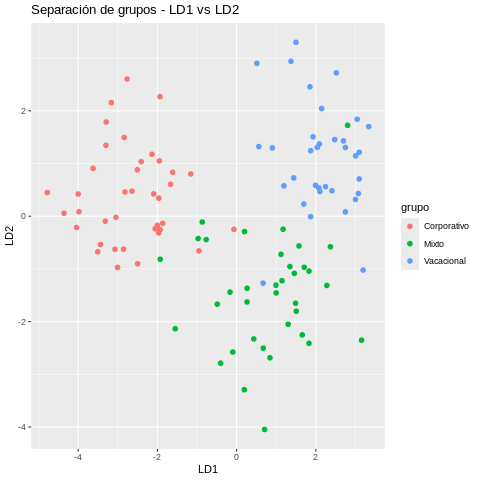

In [ ]:
%%R
#ggplot scatter LD1, y = LD2
ggplot(puntaje, aes(x = LD1, y = LD2, color = grupo)) +
  geom_point(size = 2) +
  labs(title = "Separación de grupos - LD1 vs LD2", x = "LD1", y = "LD2")

El gráfico LD1 vs LD2 muestra una separación clara entre los tres tipos de hotel. Corporativo (izquierda) se distingue bien del resto sobre el eje LD1, mientras que Vacacional (arriba a la derecha) y Mixto (abajo al centro) ocupan zonas diferenciadas, con solo algunos solapamientos en las fronteras. Esto indica que las funciones discriminantes capturan bien las diferencias operativas y comerciales entre los tres perfiles de hotel.



In [ ]:
%%R
#hago la divicion del dataset
set.seed(123)
indices <- createDataPartition(Datos_modelo$Tipo_hotel, p = 0.7, list = FALSE)

entrenamiento <- Datos_modelo[indices, ]
prueba <- Datos_modelo[-indices, ]

In [ ]:
%%R
#verifico que todo haya quedado bien (datos de entrenamiento)
table(entrenamiento$Tipo_hotel)


Corporativo       Mixto  Vacacional 
         27          26          24 


In [ ]:
%%R
#verifico que todo haya quedo bien en el conjunto de prueba
table(prueba$Tipo_hotel)


Corporativo       Mixto  Vacacional 
         11          10          10 


In [ ]:
%%R
#entrenamos el modelo
modelo_train <- lda(Tipo_hotel ~ ., data = entrenamiento)
modelo_train

Call:
lda(Tipo_hotel ~ ., data = entrenamiento)

Prior probabilities of groups:
Corporativo       Mixto  Vacacional 
  0.3506494   0.3376623   0.3116883 

Group means:
            Ocupacion_semana_pct Ocupacion_fin_semana_pct
Corporativo             80.87037                 50.14444
Mixto                   80.33462                 76.71154
Vacacional              53.04167                 80.45417
            Estancia_promedio_noches Anticipacion_reserva_dias
Corporativo                 1.781481                  10.92593
Mixto                       3.300000                  24.57692
Vacacional                  4.337500                  34.50000
            Tarifa_promedio_miles Reservas_grupales_pct Consumo_adicional_miles
Corporativo              274.1852              37.84815                99.07407
Mixto                    301.8846              30.62308               163.76923
Vacacional               301.5417              10.95833               184.87500
            Cancelaciones_pc

In [ ]:
%%R
#testeo el modelo con set de prueba e imprimo el resultado
predicciones_test <- predict(modelo_train, newdata = prueba)

tabla_confusion_test <- table(Real = prueba$Tipo_hotel, Predicho = predicciones_test$class)
tabla_confusion_test

             Predicho
Real          Corporativo Mixto Vacacional
  Corporativo          11     0          0
  Mixto                 0    10          0
  Vacacional            0     1          9


In [ ]:
%%R

precision_test <- sum(diag(tabla_confusion_test)) / sum(tabla_confusion_test)
precision_test

[1] 0.9677419


La precisión obtenida en el conjunto de prueba fue del 96.77%, un desempeño muy alto, incluso ligeramente superior al obtenido con la muestra completa (92.59%). Que la precisión en prueba no caiga respecto a la muestra completa indica que el modelo generaliza muy bien a hoteles no vistos, sin evidencia de sobreajuste; esta pequeña diferencia a favor de la prueba es atribuible al tamaño reducido del conjunto (31 hoteles). La matriz de confusión de prueba muestra que Corporativo se clasificó perfectamente (11/11) y solo hubo un error menor: un hotel Vacacional clasificado como Mixto, coherente con el ligero solapamiento observado entre estos dos perfiles en el gráfico de separación.



In [ ]:
%%R
#datos del hotel nuevo
hotel_nuevo <- data.frame(
  Ocupacion_semana_pct = 76.0,
  Ocupacion_fin_semana_pct = 72.0,
  Estancia_promedio_noches = 3.2,
  Anticipacion_reserva_dias = 24,
  Tarifa_promedio_miles = 295,
  Reservas_grupales_pct = 25.0,
  Consumo_adicional_miles = 155,
  Cancelaciones_pct = 10.5
)

In [ ]:
%%R
#se hace la prediccion del hotel
prediccion_nuevo <- predict(modelo, newdata = hotel_nuevo)
prediccion_nuevo$class

[1] Mixto
Levels: Corporativo Mixto Vacacional


In [ ]:
%%R
prediccion_nuevo$posterior

  Corporativo     Mixto Vacacional
1  0.02646566 0.8268404  0.1466939


El modelo asignó al hotel nuevo la categoría de Mixto, con una probabilidad posterior de 82.68%. Esta probabilidad es claramente dominante frente a las alternativas: Vacacional obtuvo apenas 14.67% y Corporativo solo 2.65%. Al concentrar la categoría ganadora más del 82% de la probabilidad, se considera que el modelo tiene un grado de seguridad alto en esta asignación, sin ambigüedad relevante entre clases. Este resultado es coherente con el perfil del hotel, que combina características intermedias entre lo corporativo y lo vacacional (ocupación equilibrada entre semana y fin de semana, estancia y anticipación moderadas), lo cual encaja con el tipo Mixto.

